# Toy Model: Analysis

In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
import pandas as pd
from scipy import stats


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

from sbin.complexity import ecdf_confidence, create_complexity_df
import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_semimajor_ecdf, ecdf_grid
from sbin.complexity import gap_complexity

sup_method='snow'
sample = 'confirmed'

if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor as my_suppression_factor
elif sup_method=='50':
    from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor  
elif sup_method=='snow':
    from sbin.suppression_utilities import suppression_factor_snow as my_suppression_factor
else:
    raise




### Read in data saved from Filtering

In [2]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
              
db_filtered = data["db_filtered"]  # Sullivan sample
good = data["db_rad_good"]
tb_filtered = data["tb_filtered"]  # Thebault & Bonani sample
kois_cc = data["kois_filtered_cc"] # KOIs: confirmed AND candidate
kois_confirmed = data["kois_filtered_conf"] # KOIs: confirmed ONLY
kois_good_cc = data["kois_rad_good_cc"] # KOIs: radii with reasonable errors, confirmed AND candidate

In [3]:
# separation values (as lists) for each star in binary sample
tmp = db_filtered.groupby('KOI')['SepAU'].agg('unique')
binary_separations_sullivan = np.concatenate(tmp.to_numpy())

tmp = tb_filtered.groupby('Alternate')['semi-major'].agg('unique')
binary_separations_tb = np.concatenate(tmp.to_numpy())


# Toy Model

### Suppress the KOIs

In [4]:
if sample=='confirmed':
    kois = kois_confirmed.copy()
else:
    kois = kois_cc.copy()
# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
sim = SuppressionSimulator(
    planets_cat=kois,
    sup_function=my_suppression_factor,
    sup_type="planets",
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
res_systems, res_planets  = run_trials(
    simulator=sim,
    n_trials=10)

## Semi-major axis plots

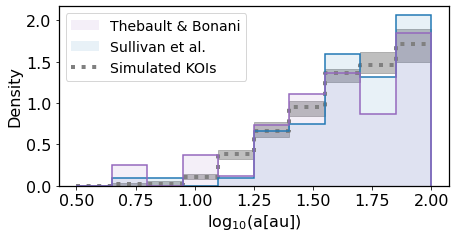

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
log_min, log_max = 0.5, 2.0              
n_bins = 10                              
bins   = np.linspace(log_min, log_max, n_bins + 1)   # bin edges

plot_hist_confidence(ax, 
                    res_systems.survived_semimajor_by_system, 
                    bins=bins,
                    log_flag=True)
ax.set_xlabel(r'$\log_{10}(a [au])$')
ax.set_ylabel('Density')

plt.hist(np.log10(binary_separations_sullivan), 
         density=True, bins=bins, histtype='step',
         color='C0', alpha=1, lw=1.5)
plt.hist(np.log10(binary_separations_sullivan), 
         density=True, bins=bins, histtype='stepfilled',
         color='C0', alpha=0.1, label='Sullivan et al.')

plt.hist(np.log10(binary_separations_tb), 
         density=True, bins=bins, histtype='step',
         color='C4', alpha=1, lw=1.5)
plt.hist(np.log10(binary_separations_tb), 
         density=True, bins=bins, histtype='stepfilled',
         color='C4', alpha=0.1, label='Thebault & Bonani')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')

plt.savefig('plots/loga_'+sup_method+'.png')

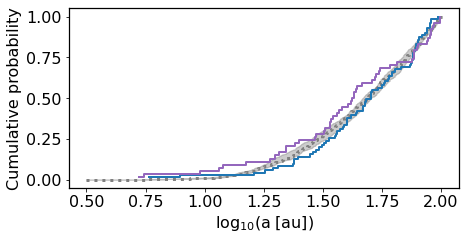

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
plot_semimajor_ecdf(ax, res_systems.survived_semimajor_by_system)

log_obs = np.log10(binary_separations_sullivan)   # work in log10 just like the sims
xs_obs, ys_obs = ecdf_grid(log_obs[log_obs<2])
plt.step(xs_obs, ys_obs, where='post',
        color='C0', lw=2, linestyle='-', label='Sullivan et al.')

log_obs = np.log10(binary_separations_tb)   # work in log10 just like the sims
xs_obs, ys_obs = ecdf_grid(log_obs[log_obs<2])
plt.step(xs_obs, ys_obs, where='post',
        color='C4', lw=2, linestyle='-', label='Thebault & Bonani')


In [7]:

def compare_observed_vs_simulated(
    a_obs,
    a_sim_trials,
    completeness_func=None,
    n_boot=5000,
    plot=True,
    seed=42,
):
    """
    Parameters
    ----------
    a_obs : 1‑D array (AU) – observed semi‑major axes.
    a_sim_trials : 2‑D array (n_trials, n_per_trial) – simulated axes.
    completeness_func : function a → detection probability (default: no filter).
    n_boot : int – # bootstrap replicates for KS distance CI.
    plot : bool – generate diagnostic plots.
    seed : int – reproducibility.
    Returns
    -------
    dict with
        ks_p_pp, ad_p_pp, energy_p_pp, ks_ci, ks_dist_obs,
        ks_dist_trials, ad_dist_trials, energy_dist_trials
    """
    rng = np.random.default_rng(seed)
    
    log_obs   = np.log10(a_obs[a_obs<100.])

    # -------------------------------------------------
    # 6.2  Distance metrics for each trial
    # -------------------------------------------------
    ks_trials    = np.empty(len(a_sim_trials))
    ad_trials    = np.empty(len(a_sim_trials))

    for i, trial in enumerate(a_sim_trials):
        log_sim  = np.log10(trial[trial<100.])   # shape (T, N_sim)
        ks_trials[i]    = stats.ks_2samp(log_obs, log_sim).pvalue
        ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).statistic
        
    print(np.percentile(ks_trials, q=[16,50,84]))
    print(np.percentile(ad_trials, q=[16,50,84]))

    
compare_observed_vs_simulated(binary_separations_sullivan, res_systems.survived_semimajor_by_system)
compare_observed_vs_simulated(binary_separations_tb, res_systems.survived_semimajor_by_system)

[0.36562484 0.69268985 0.80128296]
[-0.62922952 -0.41157899  0.31334371]
[0.10917889 0.36722755 0.57421125]
[-0.11114178  0.21675129  0.8884027 ]


/var/folders/w8/c_s9_s9d6dx1kb0j3994pjvw0000gq/T/ipykernel_13249/4083189873.py:37: UserWarning: p-value capped: true value larger than 0.25
  ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).statistic


## Multiplicity plots

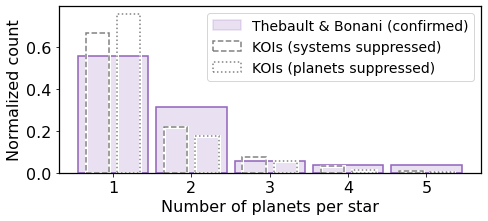

In [8]:
def multiplicity_hist(sim_results):
    
    sim_npl = np.ones((ntrials, 5))
    for i,vv in enumerate(sim_results):
        nstars = len(vv)
        ww = 1./np.full(nstars, nstars, dtype=float)
        hist, _ = np.histogram(vv, weights=ww, 
                               bins=[0.5,1.5,2.5,3.5,4.5,5.5])
        sim_npl[i] = hist
    y = np.percentile(sim_npl, q=50, axis=0)
    
    return y

if sample=='confirmed':
    bin_label = 'Thebault & Bonani (confirmed)'
    bin_col = 'C4'
    koi_label = 'KOIs (confirmed)'
    close = tb_filtered['semi-major']<100.
    bin_planet_counts = tb_filtered[close].groupby('KOI').size().reset_index(name='n_planets')
    koi_planet_counts = kois_confirmed.groupby('KOI').size().reset_index(name='n_planets')
else:
    bin_label = 'Sullivan et al. (conf+cand)'
    bin_col = 'C0'
    koi_label = 'KOIs (conf+cand)'
    close = db_filtered['SepAU']<100.
    bin_planet_counts = db_filtered[close].groupby('KOI').size().reset_index(name='n_planets')
    koi_planet_counts = kois_cc.groupby('KOI').size().reset_index(name='n_planets')
    
       
        
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])

## the binaries

nstars = len(bin_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(bin_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, edgecolor=bin_col, facecolor=bin_col, alpha=0.2, 
            width=0.9, linewidth=1.5, label=bin_label)
ax.bar(x, y, edgecolor=bin_col, facecolor='None', alpha=1, 
            width=0.9, linewidth=1.5)


## add raw planet counts

nstars = len(koi_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(koi_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x-0.2, y, ls='-', edgecolor='w', facecolor='none',  
            width=0.3, lw=3)
ax.bar(x-0.2, y, ls='--', edgecolor='gray', facecolor='None',  
            width=0.3, lw=1.5, label='KOIs (systems suppressed)')


## suppressed planet counts

nstars = len(res_planets.planet_counts_per_system)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(res_planets.planet_counts_per_system['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x+0.2, y, ls='-', edgecolor='w', facecolor='none',  
            width=0.3, lw=3)

ax.bar(x+0.2, y, ls=':', edgecolor='gray', facecolor='none',  
            width=0.3, lw=1.5, label='KOIs (planets suppressed)')


plt.xlabel('Number of planets per star')
plt.ylabel('Normalized count')
plt.legend()
plt.tight_layout()

if sample=='confirmed':
    plt.savefig('plots/multiplicity-tb.png')
else:
    plt.savefig('plots/multiplicity-sullivan.png')

# Statistics -- dont want to compare the stacked results, but individual runs

#print(stats.mannwhitneyu(bin_planet_counts['n_planets'], koi_planet_counts['n_planets'], alternative='two-sided'))

#results = [stats.mannwhitneyu(bin_planet_counts['n_planets'], x, alternative='two-sided') for x in koi_npl_sim]
#results = np.asarray(results, dtype=float)   # shape = (Nsim, 2)

#U_stats = results[:, 0]      # array of U‑statistics
#p_values  = results[:, 1]      # array of p‑values
#print(np.percentile(p_values, q=[16,50,84]))


In [9]:
nbins=20

if sample == 'confirmed':
    print("Can't do radii")
else:
    
    for option in ['linear','log']:
    
        if option=='linear':
            lin_histrange=[0.5,4.5]
            bins = np.linspace(lin_histrange[0], lin_histrange[1], nbins + 1)
        else:
            log_histrange=[np.log10(0.7),np.log10(6)]
            bins = np.logspace(log_histrange[0], log_histrange[1], nbins + 1)

        fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

        # plot the binaries
        close = db_filtered['SepAU']<100.
        nplanets = len(db_filtered[good & close])
        ww = 1./np.full(nplanets, nplanets, dtype=float)
        y, _, _ = plt.hist(db_filtered['Rppri'][good & close], 
                     bins=bins, weights=ww,
                 histtype='stepfilled', edgecolor='#1f77b4', facecolor='#e8f1f7',
                label='Close binaries')

        plt.hist(db_filtered['Rppri'][good & close], 
                     bins=bins, weights=ww,
                     histtype='stepfilled',  edgecolor='#1f77b4', facecolor='#e8f1f7')
        x = bins[:-1]+np.diff(bins)/2.
        plt.errorbar(x, y, np.sqrt(y)/len(y), ls='None', lw=1, capsize=2, c='C0')

        # plot the KOIs
        
        plot_hist_confidence(ax, 
                    res_systems.survived_planets_radii, 
                    bins=bins,
                    log_flag=False,
                    density_flag=False,
                    weights_flag=True)
        
        
        nplanets = len(kois_cc)
        ww = 1./np.full(nplanets, nplanets, dtype=float)
        y, _, _ = plt.hist(kois_cc['koi_prad'], histtype='step',
                          ls='-', edgecolor='w', lw=3,
                            weights=ww, bins=bins)
        y, _, _ = plt.hist(kois_cc['koi_prad'], histtype='step',
                          ls='--', edgecolor='gray', lw=1.5,
                            weights=ww, bins=bins)


        if option=='linear':
            plt.legend()
            plt.xlabel('$R_P$ [$R_E$]')        
        else:
            plt.xlabel('$log_{10} R_P$ [$R_E$]')  
            plt.xscale('log')

            custom_log_ticks = [1, 1.8, 3.5, 6]
            plt.gca().set_xticks(custom_log_ticks)
            plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])

        plt.ylabel('Normalized count')
        plt.tight_layout()

Can't do radii


CKS KS statistic: 0.2071
p-value: 0.9431
KOIs KS statistic: 0.3692
p-value: 0.2495


/Users/ernewton/Research/HWO_calculations/sbin/complexity.py:76: RuntimeWarning: divide by zero encountered in log
  entropy = np.sum(p_star * np.log(p_star))
/Users/ernewton/Research/HWO_calculations/sbin/complexity.py:76: RuntimeWarning: invalid value encountered in multiply
  entropy = np.sum(p_star * np.log(p_star))


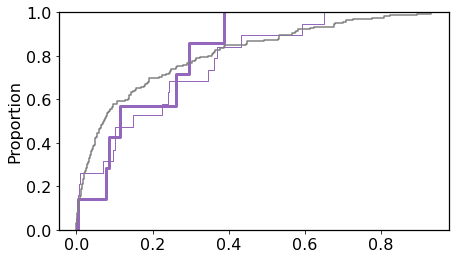

In [12]:
if sample == 'confirmed':
    bin_df = create_complexity_df(tb_filtered[tb_filtered['semi-major']<100.])
    wide_df = create_complexity_df(tb_filtered[tb_filtered['semi-major']>200.])
    koi_df = create_complexity_df(kois_confirmed)
    col = 'C4'
else:
    bin_df = create_complexity_df(db_filtered[db_filtered['SepAU']<100.])
    wide_df = create_complexity_df(db_filtered[db_filtered['SepAU']>200.])
    koi_df = create_complexity_df(kois_cc)
    col = 'C0'

    
closeb_complexity = bin_df[bin_df['n_planets']>2]['gap_complexity'].values
wideb_complexity = wide_df[wide_df['n_planets']>2]['gap_complexity'].values
koi_complexity = koi_df[koi_df['n_planets']>2]['gap_complexity'].values

fig, ax = plt.subplots(figsize=(7, 4))
sns.ecdfplot(wideb_complexity, ax=ax,
             label='Wide binaries (>200 au)', linewidth=1, color=col)
sns.ecdfplot(closeb_complexity, ax=ax,
             label='Nearby binaries (<100 au)', linewidth=3, color=col)
sns.ecdfplot(koi_complexity, ax=ax,
             label='KOIs', color='gray')


# need to add the appropriate suppressed planets for each sample option


# and the appropriate stats

ks_statistic, p_value = stats.ks_2samp(wideb_complexity, closeb_complexity)
print(f"Wide vs close KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

ks_statistic, p_value = stats.ks_2samp(closeb_complexity, koi_complexity)
print(f"Close vs KOI KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
